# Z′ $\rightarrow$ $t\bar{t}$ — Boosted Channel Search

## ATLAS Open Data reproduction of *Eur. Phys. J. C* **78** (2018) 565

**√s = 13 TeV, 10 fb⁻¹ — lepton + jets, boosted channel only**

This notebook reproduces the boosted channel of the ATLAS search for a heavy $Z'_{TC2}$ resonance decaying to top-quark pairs. The hadronic top is reconstructed as a single top-tagged large-R jet; the leptonic top from the lepton, a small-R $b$-jet, and the neutrino reconstructed via a $W$-mass constraint. Two CLs fits to the reconstruected $m_{t\bar{t}}$ spectrum set 95% CL upper limits: one with background fixed (stat-only) and one with per-bin MC statistical uncertainties profiled (Barlow-Beeston). Both are compared to validate the stat-only baseline used in the ML extension.

| Section | Content |
|---|---|
| 1 | Imports |
| 2 | Configuration |
| 3 | Per-sample normalization |
| 4 | Helper functions |
| 5 | Inspect available histograms |
| 6 | Load histograms and yield table |
| 7 | Signal normalization |
| 8 | $m_{t \bar{t}}$ distribution |
| 9 | Kinematic validation |
| 10 | Signal shapes |
| 11 | CLs fit: stat-only |
| 12 | CLs fit: Barlow-Beeston (cached) |
| 13 | Fit comparison |
| 14 | $ \sigma $ ×BR exclusion curve |
| 15 | CLs Exclusion: SUSY Signals |

# 1. Imports


In [1]:
import ROOT
ROOT.gROOT.SetBatch(True)
ROOT.gStyle.SetOptStat(0)
ROOT.gErrorIgnoreLevel = ROOT.kError
ROOT.gStyle.SetOptTitle(0)

import os
import numpy as np
import pyhf
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from IPython.display import Image, display

print(f"ROOT  {ROOT.gROOT.GetVersion()}")
print(f"pyhf  {pyhf.__version__}")
print("All imports OK")

Welcome to JupyROOT 6.30/02
ROOT  6.30/02
pyhf  0.7.6
All imports OK


# 2. Configuration

All constants in one place: paths, luminosity, signal masses, background sample groups ordered smallest-to-largest for correct THStack drawing, per-mass signal cross-sections  ($\sigma$ × BR for Z'_TC2$$), SUSY signal definitions,and the theory cross-section dict used for the exclusion curve.

In [2]:
OUTPUT_DIR = "/opt/app/atlas-open-data-code/Analysis/ZPrimeBoostedAnalysis/Output_ZPrimeBoostedAnalysis/"
FILES_TXT  = "/opt/app/atlas-open-data-code/Plotting/inputfiles/Files_ZPrime.txt"
LUMI       = 10064.0   # pb^-1

ALL_MASSES = [400, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000]

BACKGROUNDS = {
    "diboson":    ["ZqqZll", "WqqZll", "WplvWmqq", "WlvZqq", "lllv", "llvv", "lvvv"],
    "Z+jets":     ["Zee", "Zmumu", "Ztautau"],
    "single top": ["single_top_tchan", "single_antitop_tchan", "single_top_schan",
                   "single_antitop_schan", "single_top_wtchan", "single_antitop_wtchan"],
    "W+jets": [
        "Wmunu_PTV0_70_CVetoBVeto", "Wmunu_PTV0_70_CFilterBVeto", "Wmunu_PTV0_70_BFilter",
        "Wmunu_PTV70_140_CVetoBVeto", "Wmunu_PTV70_140_CFilterBVeto", "Wmunu_PTV70_140_BFilter",
        "Wmunu_PTV140_280_CVetoBVeto", "Wmunu_PTV140_280_CFilterBVeto", "Wmunu_PTV140_280_BFilter",
        "Wmunu_PTV280_500_CVetoBVeto", "Wmunu_PTV280_500_CFilterBVeto", "Wmunu_PTV280_500_BFilter",
        "Wmunu_PTV500_1000", "Wmunu_PTV1000",
        "Wenu_PTV0_70_CVetoBVeto", "Wenu_PTV0_70_CFilterBVeto", "Wenu_PTV0_70_BFilter",
        "Wenu_PTV70_140_CVetoBVeto", "Wenu_PTV70_140_CFilterBVeto", "Wenu_PTV70_140_BFilter",
        "Wenu_PTV140_280_CVetoBVeto", "Wenu_PTV140_280_CFilterBVeto", "Wenu_PTV140_280_BFilter",
        "Wenu_PTV280_500_CVetoBVeto", "Wenu_PTV280_500_CFilterBVeto", "Wenu_PTV280_500_BFilter",
        "Wenu_PTV500_1000", "Wenu_PTV1000",
        "Wtaunu_PTV0_70_CVetoBVeto", "Wtaunu_PTV0_70_CFilterBVeto", "Wtaunu_PTV0_70_BFilter",
        "Wtaunu_PTV70_140_CVetoBVeto", "Wtaunu_PTV70_140_CFilterBVeto", "Wtaunu_PTV70_140_BFilter",
        "Wtaunu_PTV140_280_CVetoBVeto", "Wtaunu_PTV140_280_CFilterBVeto", "Wtaunu_PTV140_280_BFilter",
        "Wtaunu_PTV280_500_CVetoBVeto", "Wtaunu_PTV280_500_CFilterBVeto", "Wtaunu_PTV280_500_BFilter",
        "Wtaunu_PTV500_1000", "Wtaunu_PTV1000",
    ],
    "ttbar": ["ttbar_lep"],
}

FILL_COLORS = {
    "diboson":    ROOT.kRed-7,
    "Z+jets":     ROOT.kCyan-9,
    "single top": ROOT.kOrange-3,
    "W+jets":     ROOT.kGreen-9,
    "ttbar":      ROOT.kAzure+1,
}

# Z'_TC2 sigma*BR [pb] — teacher's table
SIGNAL_XSEC = {
    400: 8.99, 500: 8.74, 750: 3.12, 1000: 1.13,
    1250: 0.460, 1500: 0.207, 1750: 0.100, 2000: 0.0513,
    2250: 0.0275, 2500: 0.0152, 2750: 0.00869, 3000: 0.00508,
}
SUMW_SIGNAL = 199800.0
SIGNAL_SCFS = {mass: (LUMI * xsec) / SUMW_SIGNAL for mass, xsec in SIGNAL_XSEC.items()}

# Theory cross-sections for exclusion curve (same values as SIGNAL_XSEC)
theory_xsec = {
    400: 8.99, 500: 8.74, 750: 3.12, 1000: 1.13,
    1250: 0.460, 1500: 0.207, 1750: 0.100, 2000: 0.0513,
    2250: 0.0275, 2500: 0.0152, 2750: 0.00869, 3000: 0.00508,
}

# SUSY signal models
SUSY_SIGNALS = {
    "GG_ttn1_1200_5000_1":   {"xsec": 0.057,  "sumw": 100000, "label": r"$\tilde{g}$ 1200 GeV, LSP 1 GeV"},
    "GG_ttn1_1200_5000_600": {"xsec": 0.057,  "sumw": 100000, "label": r"$\tilde{g}$ 1200 GeV, LSP 600 GeV"},
    "GG_ttn1_1400_5000_1":   {"xsec": 0.0158, "sumw": 100000, "label": r"$\tilde{g}$ 1400 GeV, LSP 1 GeV"},
    "GG_ttn1_1600_5000_1":   {"xsec": 0.0475, "sumw": 100000, "label": r"$\tilde{g}$ 1600 GeV, LSP 1 GeV"},
    "TT_directTT_450_1":     {"xsec": 0.884,  "sumw":  50000, "label": r"$\tilde{t}$ 450 GeV, LSP 1 GeV"},
    "TT_directTT_500_1":     {"xsec": 0.466,  "sumw":  20000, "label": r"$\tilde{t}$ 500 GeV, LSP 1 GeV"},
    "TT_directTT_500_200":   {"xsec": 0.467,  "sumw":  50000, "label": r"$\tilde{t}$ 500 GeV, LSP 200 GeV"},
    "TT_directTT_600_1":     {"xsec": 0.155,  "sumw":  50000, "label": r"$\tilde{t}$ 600 GeV, LSP 1 GeV"},
}
SUSY_SCFS = {name: (LUMI * info["xsec"]) / info["sumw"] for name, info in SUSY_SIGNALS.items()}

print(f"Output dir exists : {os.path.exists(OUTPUT_DIR)}")
print(f"Files_ZPrime.txt  : {os.path.exists(FILES_TXT)}")
print(f"Luminosity        : {LUMI} pb^-1")

Output dir exists : True
Files_ZPrime.txt  : True
Luminosity        : 10064.0 pb^-1


## 3. Per-Sample Normalization

Each MC sample is scaled by

$$\mathrm{scf} = \frac{\mathcal{L}\,\sigma}{\sum w_{\mathrm{gen}}\;\varepsilon_{\mathrm{filter}}}$$

read from `Files_ZPrime.txt`: the same normalization `Plotting.C`. Data samples always get `scf = 1.0`.

In [3]:
def load_scale_factors(filepath, lumi):
    """
    Read Files_ZPrime.txt and compute per-sample scale factors.
    Replicates Plotting.C: scf = (lumi * xsec) / (sumw * eff).
    Data samples get scf = 1.0 and are never rescaled.
    """
    scale_factors = {}
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split("|")
            if len(parts) < 4:
                continue
            name = parts[0].strip()
            xsec = float(parts[1].strip())
            sumw = float(parts[2].strip())
            eff  = float(parts[3].strip())
            if "data" in name.lower():
                scale_factors[name] = 1.0
            else:
                sumw_eff = sumw * eff
                scale_factors[name] = (lumi * xsec) / sumw_eff if sumw_eff != 0 else 1.0
    return scale_factors


SCALE_FACTORS = load_scale_factors(FILES_TXT, LUMI)

print(f"Loaded {len(SCALE_FACTORS)} samples\n")
print(f"  {'sample':<45}  {'scf':>12}")
print("  " + "-"*60)
for name, scf in list(SCALE_FACTORS.items())[:10]:
    print(f"  {name:<45}  {scf:>12.6f}")
print("  ...")
print(f"\n  ttbar_lep scf = {SCALE_FACTORS.get('ttbar_lep'):.6f}")

Loaded 74 samples

  sample                                                  scf
  ------------------------------------------------------------
  data                                               1.000000
  ttbar_lep                                          0.092418
  single_top_tchan                                   0.089115
  single_antitop_tchan                               0.052996
  single_top_schan                                   0.020790
  single_antitop_schan                               0.013029
  single_top_wtchan                                  0.074140
  single_antitop_wtchan                              0.072901
  Wmunu_PTV0_70_CVetoBVeto                           9.275487
  Wmunu_PTV0_70_CFilterBVeto                         4.335467
  ...

  ttbar_lep scf = 0.092418


## 4. Helper Functions

All function definitions live here. Execution cells only call these — no
definitions appear elsewhere in the notebook.

**I/O:** `get_hist`, `get_merged_hist` (with 0.91 tt̄ correction),
`hist_to_numpy`, `hist_to_numpy_with_errors`, `list_histograms`

**Plotting:** `make_two_panel_plot` (m_tt and any stacked+ratio plot),
`make_kinematic_plot` (builds its own local stack per histogram)

**CLs fit:** `run_cls_fit` (stat-only or Barlow-Beeston via `use_mcstat` flag,
returns observed limit and 5 expected quantiles)

**Exclusion curve:** `make_xs_arrays` (converts μ limits to σ×BR)

In [4]:
keep_alive = []

# I/O helpers 

def get_hist(sample_name, hist_name):
    """Open ROOT file, clone histogram, apply scale factor."""
    path = os.path.join(OUTPUT_DIR, sample_name + ".root")
    if not os.path.exists(path):
        return None
    f = ROOT.TFile(path, "READ")
    h = f.Get(hist_name)
    if not h:
        f.Close()
        return None
    clone = h.Clone(f"{sample_name}__{hist_name}")
    clone.SetDirectory(0)
    f.Close()
    scf = SCALE_FACTORS.get(sample_name, None)
    if scf is not None and scf != 1.0:
        clone.Scale(scf)
    return clone


def get_merged_hist(sample_list, hist_name, out_name):
    """Sum a background group. Apply 0.91 ttbar correction for non-LR histograms."""
    total = None
    for name in sample_list:
        h = get_hist(name, hist_name)
        if h is None:
            continue
        if total is None:
            total = h.Clone(out_name)
            total.SetDirectory(0)
        else:
            total.Add(h)
    if total is not None and out_name == "h_bkg_ttbar":
        if "leadLR" not in hist_name and "LRjet" not in hist_name:
            total.Scale(0.91)
    return total


def hist_to_numpy(h):
    """TH1F -> (edges[n+1], values[n])."""
    n = h.GetNbinsX()
    edges  = np.array([h.GetBinLowEdge(i) for i in range(1, n + 2)])
    values = np.array([h.GetBinContent(i)  for i in range(1, n + 1)])
    return edges, values


def hist_to_numpy_with_errors(h):
    """TH1F -> (edges[n+1], values[n], errors[n]).
    errors[i] = sqrt(sum_w2) per bin — MC statistical uncertainty."""
    n = h.GetNbinsX()
    edges  = np.array([h.GetBinLowEdge(i) for i in range(1, n + 2)])
    values = np.array([h.GetBinContent(i)  for i in range(1, n + 1)])
    errors = np.array([h.GetBinError(i)    for i in range(1, n + 1)])
    return edges, values, errors


def list_histograms(sample_name):
    """Print all TH1 objects in a ROOT file with bin count and integral."""
    path = os.path.join(OUTPUT_DIR, sample_name + ".root")
    f = ROOT.TFile(path, "READ")
    print(f"Histograms in {sample_name}.root:\n")
    for key in f.GetListOfKeys():
        obj = key.ReadObj()
        if obj.InheritsFrom("TH1"):
            print(f"  {key.GetName():<38}  {obj.GetNbinsX():>3} bins"
                  f"   integral = {obj.Integral():.1f}")
    f.Close()


# plotting helpers 

def make_two_panel_plot(stack, h_total, h_dat, sig_hists_dict, x_label, out_file, logy=False, sig_mass=1000, sig_scale=10):
    
    """Two-panel canvas: stacked backgrounds + data (top), Data/MC ratio (bottom)."""

    c = ROOT.TCanvas(f"c_{out_file}", out_file, 900, 850)
    c.cd()
    p1 = ROOT.TPad(f"p1_{out_file}", "main", 0, 0.29, 1, 1.0)
    p1.SetBottomMargin(0.02); p1.SetTopMargin(0.07)
    p1.SetLeftMargin(0.14);   p1.SetRightMargin(0.05)
    if logy: p1.SetLogy(True)
    p1.Draw(); p1.cd()
    stack.Draw("hist")
    stack.SetMinimum(0.5 if logy else 0)
    stack.SetMaximum(stack.GetMaximum("nostack") * (200 if logy else 1.4))
    stack.GetXaxis().SetLabelSize(0)
    stack.GetYaxis().SetTitle("Events / bin")
    stack.GetYaxis().SetTitleSize(0.055)
    stack.GetYaxis().SetTitleOffset(1.1)
    h_dat.Draw("ep same")
    h_s_drawn = None
    if sig_mass in sig_hists_dict:
        h_s_drawn = sig_hists_dict[sig_mass].Clone(f"sig_{sig_mass}_{out_file}")
        h_s_drawn.SetDirectory(0)
        h_s_drawn.Scale(sig_scale)
        h_s_drawn.SetLineColor(ROOT.kRed)
        h_s_drawn.SetLineWidth(2)
        h_s_drawn.SetLineStyle(2)
        h_s_drawn.Draw("hist same")
        keep_alive.append(h_s_drawn)
    leg = ROOT.TLegend(0.62, 0.50, 0.93, 0.90)
    leg.SetBorderSize(0); leg.SetFillStyle(0); leg.SetTextSize(0.042)
    leg.AddEntry(h_dat, "Data", "ep")
    for group in reversed(list(FILL_COLORS.keys())):
        if group in bkg_hists:
            leg.AddEntry(bkg_hists[group], group, "f")
    if h_s_drawn:
        leg.AddEntry(h_s_drawn, f"Z' {sig_mass} GeV #times{sig_scale}", "l")
    leg.Draw(); keep_alive.append(leg)
    latex = ROOT.TLatex(); latex.SetNDC()
    latex.SetTextSize(0.045)
    latex.DrawLatex(0.16, 0.88, "#bf{ATLAS} Open Data")
    latex.SetTextSize(0.038)
    latex.DrawLatex(0.16, 0.83, "#sqrt{s} = 13 TeV, 10 fb^{-1}")
    latex.DrawLatex(0.16, 0.78, "Z' #rightarrow t#bar{t} boosted")
    keep_alive.append(latex)
    c.cd()
    p2 = ROOT.TPad(f"p2_{out_file}", "ratio", 0, 0.0, 1, 0.29)
    p2.SetTopMargin(0.03); p2.SetBottomMargin(0.38)
    p2.SetLeftMargin(0.14); p2.SetRightMargin(0.05)
    p2.Draw(); p2.cd()
    h_ratio = h_dat.Clone(f"ratio_{out_file}")
    h_ratio.SetDirectory(0)
    h_ratio.Divide(h_total)
    h_ratio.SetMarkerStyle(20); h_ratio.SetMarkerSize(0.9)
    h_ratio.SetMinimum(0.0);    h_ratio.SetMaximum(2.0)
    h_ratio.GetYaxis().SetTitle("Data / MC")
    h_ratio.GetYaxis().SetNdivisions(504)
    h_ratio.GetYaxis().SetTitleSize(0.13); h_ratio.GetYaxis().SetTitleOffset(0.38)
    h_ratio.GetYaxis().SetLabelSize(0.11)
    h_ratio.GetXaxis().SetTitle(x_label)
    h_ratio.GetXaxis().SetTitleSize(0.14); h_ratio.GetXaxis().SetTitleOffset(1.1)
    h_ratio.GetXaxis().SetLabelSize(0.12)
    h_ratio.Draw("ep"); keep_alive.append(h_ratio)
    ref = ROOT.TLine(h_ratio.GetXaxis().GetXmin(), 1.0,
                     h_ratio.GetXaxis().GetXmax(), 1.0)
    ref.SetLineStyle(2); ref.SetLineColor(ROOT.kRed); ref.SetLineWidth(2)
    ref.Draw(); keep_alive.append(ref)
    c.Print(out_file); keep_alive.append(c)
    return out_file


def make_kinematic_plot(hist_name, x_label, out_file,
                        logy=True, sig_mass=1000, sig_scale=100):
    """Two-panel validation plot for any kinematic histogram."""
    local_stack = ROOT.THStack(f"stack_{hist_name}", "")
    local_bkg   = {}
    local_total = None
    for group, samples in BACKGROUNDS.items():
        h = get_merged_hist(samples, hist_name, f"h_{group}_{hist_name}")
        if h is None:
            continue
        h.SetFillColor(FILL_COLORS[group])
        h.SetLineColor(ROOT.kBlack)
        h.SetLineWidth(1)
        local_bkg[group] = h
        local_stack.Add(h)
        keep_alive.append(h)
        if local_total is None:
            local_total = h.Clone(f"total_{hist_name}")
            local_total.SetDirectory(0)
        else:
            local_total.Add(h)
    if local_total is None:
        print(f"No background for {hist_name}"); return
    keep_alive.append(local_total)
    h_dat = get_hist("data", hist_name)
    if h_dat is None:
        print(f"No data for {hist_name}"); return
    h_dat.SetMarkerStyle(20); h_dat.SetMarkerSize(1.1)
    h_dat.SetLineColor(ROOT.kBlack)
    keep_alive.append(h_dat)
    local_sig = {}
    h_s = get_hist(f"ZPrime{sig_mass}_tt", hist_name)
    if h_s is not None:
        h_s.Scale(SIGNAL_SCFS[sig_mass])
        local_sig[sig_mass] = h_s
        keep_alive.append(h_s)
    c = ROOT.TCanvas(f"c_{hist_name}", hist_name, 900, 850)
    c.cd()
    p1 = ROOT.TPad(f"p1_{hist_name}", "main", 0, 0.29, 1, 1.0)
    p1.SetBottomMargin(0.02); p1.SetTopMargin(0.07)
    p1.SetLeftMargin(0.14);   p1.SetRightMargin(0.05)
    if logy: p1.SetLogy(True)
    p1.Draw(); p1.cd()
    local_stack.Draw("hist")
    local_stack.SetMinimum(0.5 if logy else 0)
    local_stack.SetMaximum(local_stack.GetMaximum("nostack") * (200 if logy else 1.4))
    local_stack.GetXaxis().SetLabelSize(0)
    local_stack.GetYaxis().SetTitle("Events / bin")
    local_stack.GetYaxis().SetTitleSize(0.055)
    local_stack.GetYaxis().SetTitleOffset(1.1)
    h_dat.Draw("ep same")
    h_s_drawn = None
    if sig_mass in local_sig:
        h_s_drawn = local_sig[sig_mass].Clone(f"sig_{sig_mass}_{hist_name}")
        h_s_drawn.SetDirectory(0)
        h_s_drawn.Scale(sig_scale)
        h_s_drawn.SetLineColor(ROOT.kRed)
        h_s_drawn.SetLineWidth(2)
        h_s_drawn.SetLineStyle(2)
        h_s_drawn.Draw("hist same")
        keep_alive.append(h_s_drawn)
    leg = ROOT.TLegend(0.62, 0.50, 0.93, 0.90)
    leg.SetBorderSize(0); leg.SetFillStyle(0); leg.SetTextSize(0.042)
    leg.AddEntry(h_dat, "Data", "ep")
    for group in reversed(list(FILL_COLORS.keys())):
        if group in local_bkg:
            leg.AddEntry(local_bkg[group], group, "f")
    if h_s_drawn:
        leg.AddEntry(h_s_drawn, f"Z' {sig_mass} GeV #times{sig_scale}", "l")
    leg.Draw(); keep_alive.append(leg)
    latex = ROOT.TLatex(); latex.SetNDC(); latex.SetTextSize(0.045)
    latex.DrawLatex(0.16, 0.88, "#bf{ATLAS} Open Data")
    latex.SetTextSize(0.038)
    latex.DrawLatex(0.16, 0.83, "#sqrt{s} = 13 TeV, 10 fb^{-1}")
    keep_alive.append(latex)
    c.cd()
    p2 = ROOT.TPad(f"p2_{hist_name}", "ratio", 0, 0.0, 1, 0.29)
    p2.SetTopMargin(0.03); p2.SetBottomMargin(0.38)
    p2.SetLeftMargin(0.14); p2.SetRightMargin(0.05)
    p2.Draw(); p2.cd()
    h_ratio = h_dat.Clone(f"ratio_{hist_name}")
    h_ratio.SetDirectory(0)
    h_ratio.Divide(local_total)
    h_ratio.SetMarkerStyle(20); h_ratio.SetMarkerSize(0.9)
    h_ratio.SetMinimum(0.0);    h_ratio.SetMaximum(2.0)
    h_ratio.GetYaxis().SetTitle("Data / MC")
    h_ratio.GetYaxis().SetNdivisions(504)
    h_ratio.GetYaxis().SetTitleSize(0.13); h_ratio.GetYaxis().SetTitleOffset(0.38)
    h_ratio.GetYaxis().SetLabelSize(0.11)
    h_ratio.GetXaxis().SetTitle(x_label)
    h_ratio.GetXaxis().SetTitleSize(0.14); h_ratio.GetXaxis().SetTitleOffset(1.1)
    h_ratio.GetXaxis().SetLabelSize(0.12)
    h_ratio.Draw("ep"); keep_alive.append(h_ratio)
    ref = ROOT.TLine(h_ratio.GetXaxis().GetXmin(), 1.0,
                     h_ratio.GetXaxis().GetXmax(), 1.0)
    ref.SetLineStyle(2); ref.SetLineColor(ROOT.kRed); ref.SetLineWidth(2)
    ref.Draw(); keep_alive.append(ref)
    c.Print(out_file); keep_alive.append(c)
    display(Image(out_file, width=700))


#  CLs fit helpers 

def run_cls_fit(signal, n_scan=150, use_mcstat=False):
    """CL_s scan for one Z' mass. Returns (obs_lim, exp_lims[5]).
    exp_lims order: [-2s, -1s, median, +1s, +2s]
    """
    h_sig = sig_hists.get(signal) if isinstance(signal, int) else susy_hists.get(signal)
    if h_sig is None:
        return None, None
    if use_mcstat:
        _, s, _     = hist_to_numpy_with_errors(h_sig)
        _, b, b_err = hist_to_numpy_with_errors(h_bkg_total)
        _, n, _     = hist_to_numpy_with_errors(h_data)
    else:
        _, s = hist_to_numpy(h_sig)
        _, b = hist_to_numpy(h_bkg_total)
        _, n = hist_to_numpy(h_data)
        b_err = None
    keep = b > 0
    s, b, n = s[keep], b[keep], n[keep]
    if b_err is not None:
        b_err = b_err[keep]
    if s.sum() < 1e-6:
        return 1e3, [1e3]*5
    if use_mcstat:
        spec = {"channels": [{"name": "SR", "samples": [
            {"name": "signal", "data": [float(x) for x in s],
             "modifiers": [{"name": "mu", "type": "normfactor", "data": None}]},
            {"name": "background", "data": [float(x) for x in b],
             "modifiers": [{"name": "mcstat", "type": "staterror",
                            "data": [float(x) for x in b_err]}]},
        ]}]}
    else:
        spec = {"channels": [{"name": "SR", "samples": [
            {"name": "signal", "data": [float(x) for x in s],
             "modifiers": [{"name": "mu", "type": "normfactor", "data": None}]},
            {"name": "background", "data": [float(x) for x in b],
             "modifiers": []},
        ]}]}
    model = pyhf.Model(spec, poi_name="mu")
    data  = list(n) + model.config.auxdata
    fisher    = float(np.sum(s**2 / b))
    mu_est    = 1.64 / np.sqrt(fisher) if fisher > 0 else 100.0
    mu_hi     = max(6.0 * mu_est, 2.0)
    scan      = np.linspace(0.0, mu_hi, n_scan)[1:]
    init_pars  = model.config.suggested_init()
    par_bounds = model.config.suggested_bounds()
    par_bounds[model.config.poi_index] = (0.0, max(mu_hi * 1.1, 5.0))
    obs_cls, exp_cls = [], [[], [], [], [], []]
    for mu in scan:
        try:
            result = pyhf.infer.hypotest(mu, data, model, test_stat="qtilde",
                                         return_expected_set=True,
                                         init_pars=init_pars, par_bounds=par_bounds)
            obs_cls.append(float(result[0]))
            for qi in range(5): exp_cls[qi].append(float(result[1][qi]))
        except Exception:
            obs_cls.append(np.nan)
            for qi in range(5): exp_cls[qi].append(np.nan)
    obs_cls = np.array(obs_cls)
    exp_cls = [np.array(q) for q in exp_cls]
    def crossing(mu_scan, cls):
        good = np.isfinite(cls)
        mu_g, cls_g = mu_scan[good], cls[good]
        if len(cls_g) < 2: return float(mu_scan[-1])
        for i in range(len(cls_g) - 1):
            if cls_g[i] >= 0.05 >= cls_g[i+1]:
                f = (cls_g[i] - 0.05) / (cls_g[i] - cls_g[i+1])
                return float(mu_g[i] + f * (mu_g[i+1] - mu_g[i]))
        if cls_g[0] < 0.05: return float(mu_g[0])
        return float(mu_scan[-1])
    obs_lim  = crossing(scan, obs_cls)
    exp_lims = [crossing(scan, exp_cls[qi]) for qi in range(5)]
    return obs_lim, exp_lims


# exclusion curve helper 

def make_xs_arrays(results):
    """Convert mu limits dict to sigma*BR arrays using theory_xsec."""
    th = np.array([theory_xsec[m] for m in ALL_MASSES])
    obs = np.array([results[m]["obs"]    for m in ALL_MASSES])
    exp = np.array([results[m]["exp"]    for m in ALL_MASSES])
    m1  = np.array([results[m]["exp_m1"] for m in ALL_MASSES])
    p1  = np.array([results[m]["exp_p1"] for m in ALL_MASSES])
    m2  = np.array([results[m]["exp_m2"] for m in ALL_MASSES])
    p2  = np.array([results[m]["exp_p2"] for m in ALL_MASSES])
    return obs*th, exp*th, m1*th, p1*th, m2*th, p2*th


print("All helper functions defined.")

All helper functions defined.


## 5. Inspect Available Histograms

List every histogram stored in one sample's ROOT file with its bin count and
integral, to confirm the selector wrote what we expect — in particular
`hist_ttbarMLR`, the fit observable, now binned 30 × 100 GeV over 400–3400 GeV.

In [5]:
list_histograms("ttbar_lep")

Histograms in ttbar_lep.root:

  hist_etmiss                              30 bins   integral = 144987.9
  hist_mtw                                 30 bins   integral = 146176.9
  hist_leadleptpt                          20 bins   integral = 146120.0
  hist_leadlepteta                         30 bins   integral = 147162.2
  hist_leadleptE                           30 bins   integral = 140036.6
  hist_leadleptphi                         32 bins   integral = 147162.2
  hist_leadleptch                           7 bins   integral = 147162.4
  hist_leadleptID                          15 bins   integral = 147162.0
  hist_leadlept_ptc                        20 bins   integral = 0.0
  hist_leadleptetc                         20 bins   integral = 0.0
  hist_leadlepz0                           20 bins   integral = 0.0
  hist_leadlepd0                           20 bins   integral = 0.0
  hist_n_jets                               4 bins   integral = 141072.0
  hist_leadjet_pt                       

## 6. Load Histograms and Yield Table

Build the stacked background, the total background, and the data histogram for
the fit observable `hist_ttbarMLR`. The yield table compares the total MC
prediction to data, agreement near **Data/MC ≈ 1.0** confirms the
normalization is correct.

Event yield table (after luminosity normalization):

  diboson                 6.9
  Z+jets                  1.0
  single top            313.1
  W+jets                174.2
  ttbar               8,130.6
  ──────────────────────────────
  Total MC            8,625.9
  Data                  8,472

  Data / MC = 0.9822   (target: ~1.0)


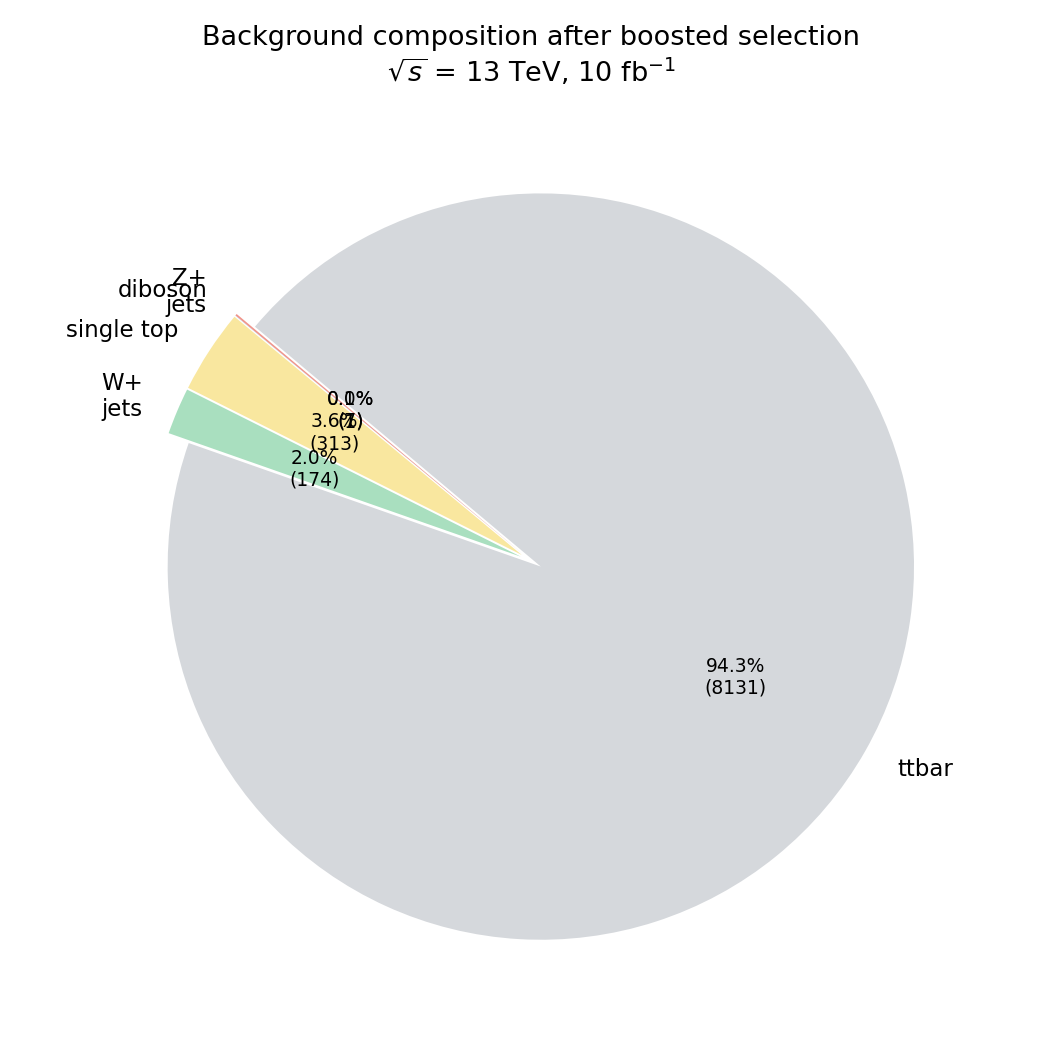

In [6]:
TARGET = "hist_ttbarMLR"   # main fit observable: reconstructed m_tt

# backgrounds 
bkg_hists = {}
bkg_stack  = ROOT.THStack("stack_mtt", "")

for group, samples in BACKGROUNDS.items():
    h = get_merged_hist(samples, TARGET, f"h_bkg_{group}")
    if h is None:
        print(f"  WARNING: no histogram found for group '{group}'")
        continue
    h.SetFillColor(FILL_COLORS[group])
    h.SetLineColor(ROOT.kBlack)
    h.SetLineWidth(1)
    bkg_hists[group] = h
    bkg_stack.Add(h)
    keep_alive.append(h)

h_bkg_total = None
for h in bkg_hists.values():
    if h_bkg_total is None:
        h_bkg_total = h.Clone("h_bkg_total")
        h_bkg_total.SetDirectory(0)
    else:
        h_bkg_total.Add(h)
keep_alive.append(h_bkg_total)

# data 
h_data = get_hist("data", TARGET)
h_data.SetMarkerStyle(20)
h_data.SetMarkerSize(1.2)
h_data.SetLineColor(ROOT.kBlack)
keep_alive.append(h_data)

# yield table
print("Event yield table (after luminosity normalization):\n")
total_mc = 0.0
for group, h in bkg_hists.items():
    n = h.Integral()
    total_mc += n
    print(f"  {group:<15}  {n:>10,.1f}")
print(f"  {'─'*30}")
print(f"  {'Total MC':<15}  {total_mc:>10,.1f}")
print(f"  {'Data':<15}  {h_data.Integral():>10,.0f}")
print(f"\n  Data / MC = {h_data.Integral() / total_mc:.4f}   (target: ~1.0)")


pie_groups  = list(bkg_hists.keys())
pie_yields  = [bkg_hists[g].Integral() for g in pie_groups]
pie_colors  = ["#F1948A", "#AED6F1", "#F9E79F", "#A9DFBF", "#D5D8DC"]
pie_explode = [0.03] * len(pie_groups)

fig_pie, ax_pie = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax_pie.pie(
    pie_yields,
    labels=[g.replace("+", "+\n") for g in pie_groups],
    colors=pie_colors,
    explode=pie_explode,
    autopct=lambda p: f"{p:.1f}%\n({p*sum(pie_yields)/100:.0f})",
    startangle=140,
    textprops={"fontsize": 11},
)
for at in autotexts:
    at.set_fontsize(9)
ax_pie.set_title(
    r"Background composition after boosted selection" + "\n" +
    r"$\sqrt{s}$ = 13 TeV, 10 fb$^{-1}$",
    fontsize=13
)
plt.tight_layout()
plt.savefig("bkg_piechart.png", dpi=150)
plt.close()
display(Image("bkg_piechart.png", width=600))

## 7. Signal Normalization

Each Z′ signal mass point is normalized with its **own** cross-section from
the teacher's table (σ×BR for the Z′_TC2 model, sumw = 199 800 for all samples):

$$\text{scf}(m) = \frac{\mathcal{L} \times \sigma_{\text{theory}}(m)}{\sum w_{\text{gen}}}$$

μ = 1 now means: the data is consistent with exactly the predicted signal
cross-section for that mass. μ < 1 → excluded at 95% CL.

In [7]:
# Z' signal histograms 
sig_hists = {}
for mass in ALL_MASSES:
    name = f"ZPrime{mass}_tt"
    path = os.path.join(OUTPUT_DIR, name + ".root")
    f = ROOT.TFile(path, "READ")
    h = f.Get(TARGET)
    if h:
        clone = h.Clone(f"{name}__{TARGET}")
        clone.SetDirectory(0)
        clone.Scale(SIGNAL_SCFS[mass])
        sig_hists[mass] = clone
        keep_alive.append(clone)
    f.Close()

print("Z' signal yields:\n")
print(f"  {'mass':>6}   {'xsec [pb]':>10}   {'scf':>10}   {'yield':>8}")
print("  " + "-"*46)
for mass in ALL_MASSES:
    if mass in sig_hists:
        print(f"  Z' {mass:>4} GeV   {SIGNAL_XSEC[mass]:>10.5f}   "
              f"{SIGNAL_SCFS[mass]:>10.6f}   {sig_hists[mass].Integral():>8.1f}")

#  SUSY signal histograms 
susy_hists = {}
for name, info in SUSY_SIGNALS.items():
    path = os.path.join(OUTPUT_DIR, name + ".root")
    f = ROOT.TFile(path, "READ")
    h = f.Get(TARGET)
    if h:
        clone = h.Clone(f"{name}__{TARGET}")
        clone.SetDirectory(0)
        clone.Scale(SUSY_SCFS[name])
        susy_hists[name] = clone
        keep_alive.append(clone)
        print(f"  {name:<28}   {clone.Integral():>8.2f} events")
    else:
        print(f"  {name:<28}   NOT FOUND")
    f.Close()

print(f"\n  Loaded {len(susy_hists)} / {len(SUSY_SIGNALS)} SUSY signal samples")

Z' signal yields:

    mass    xsec [pb]          scf      yield
  ----------------------------------------------
  Z'  400 GeV      8.99000     0.452830       17.2
  Z'  500 GeV      8.74000     0.440237       23.8
  Z'  750 GeV      3.12000     0.157156      167.7
  Z' 1000 GeV      1.13000     0.056919      291.3
  Z' 1250 GeV      0.46000     0.023170      171.0
  Z' 1500 GeV      0.20700     0.010427       83.0
  Z' 1750 GeV      0.10000     0.005037       37.6
  Z' 2000 GeV      0.05130     0.002584       17.7
  Z' 2250 GeV      0.02750     0.001385        8.5
  Z' 2500 GeV      0.01520     0.000766        4.2
  Z' 2750 GeV      0.00869     0.000438        2.0
  Z' 3000 GeV      0.00508     0.000256        1.0
  GG_ttn1_1200_5000_1               31.52 events
  GG_ttn1_1200_5000_600             16.21 events
  GG_ttn1_1400_5000_1                9.17 events
  GG_ttn1_1600_5000_1               25.97 events
  TT_directTT_450_1                 66.97 events
  TT_directTT_500_1          

## 8. $m_{t\bar{t}}$ Distribution with Data/MC Ratio Panel

The fit observable after neutrino $p_z$ reconstruction. Stacked backgrounds,
data points, and the $Z'$ 1 TeV signal overlaid ×10.

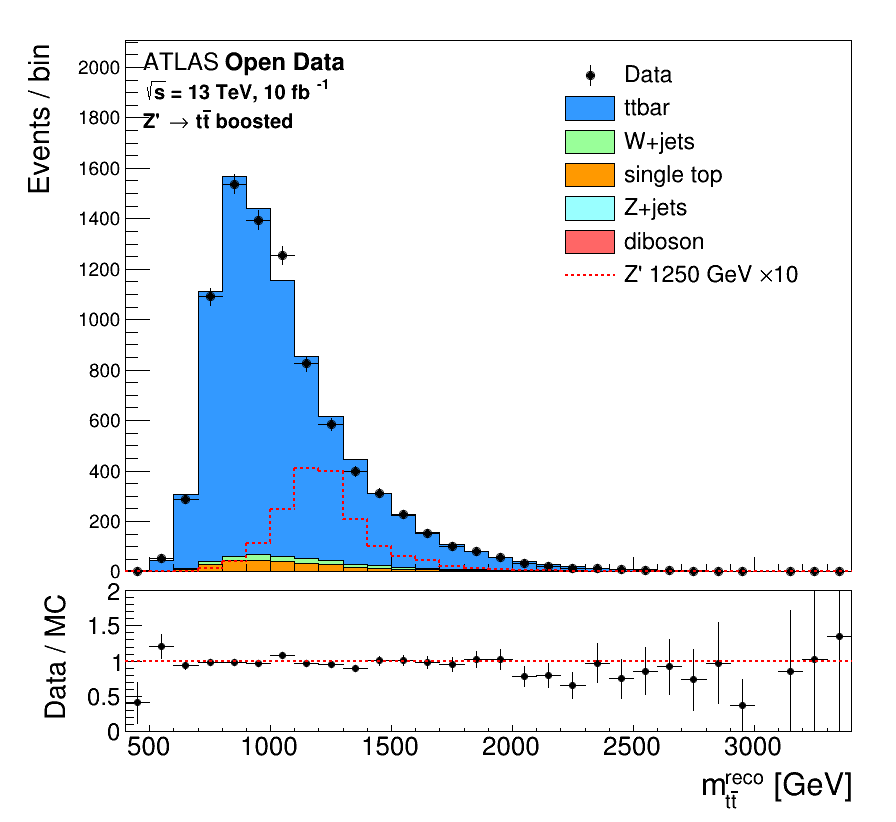

In [27]:

out = make_two_panel_plot(bkg_stack, h_bkg_total, h_data, sig_hists, "m_{t#bar{t}}^{reco} [GeV]", "mttbar_ratio.png", logy=False, sig_mass=1250, sig_scale=10)
display(Image(out, width=750))


## 9. Kinematic Validation Plots

Six input distributions (lepton $p_T$, $E_T^{\rm miss}$, top-tagged jet $p_T$
and mass, $\tau_{32}$, $m_T^W$) with Data/MC ratio panels. Good shape agreement across all of them validates the selection and normalization. The $Z'$ 1 TeV signal is overlaid ×100. Known MC-modelling features (e.g. the data dip around the top-mass peak at 175–200 GeV) are also present in the paper's Figure 9.

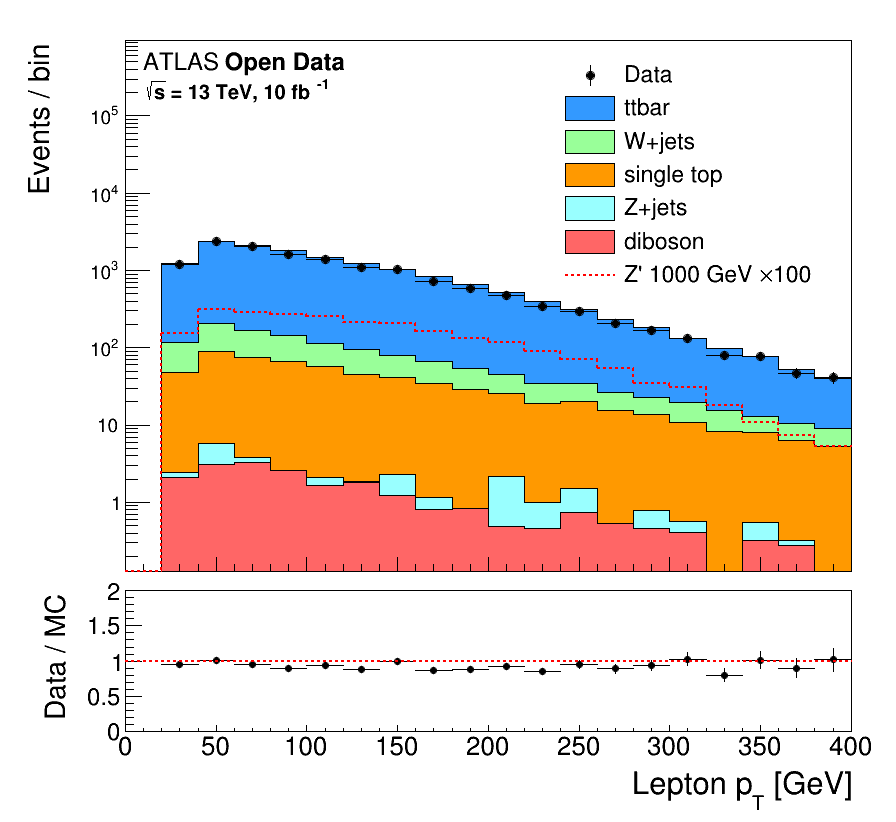

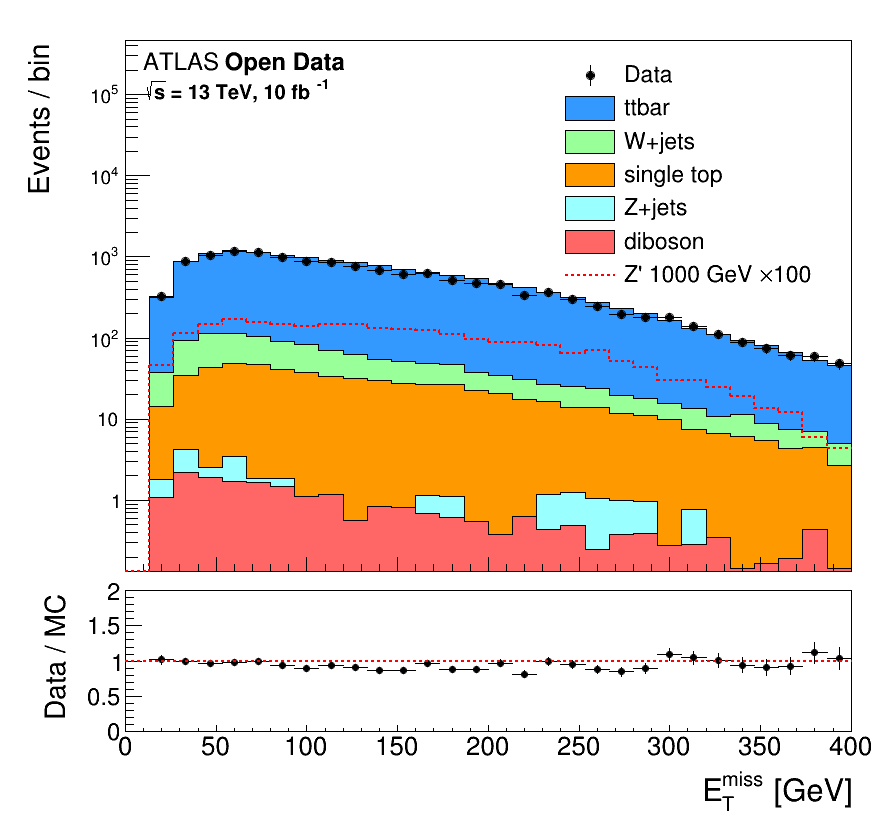

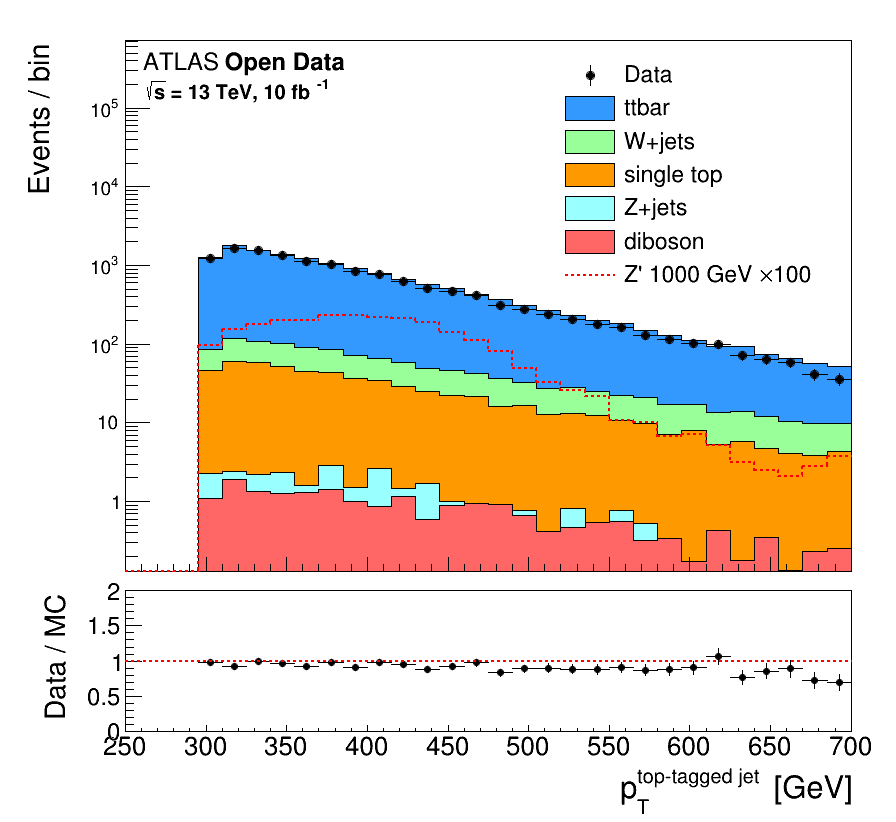

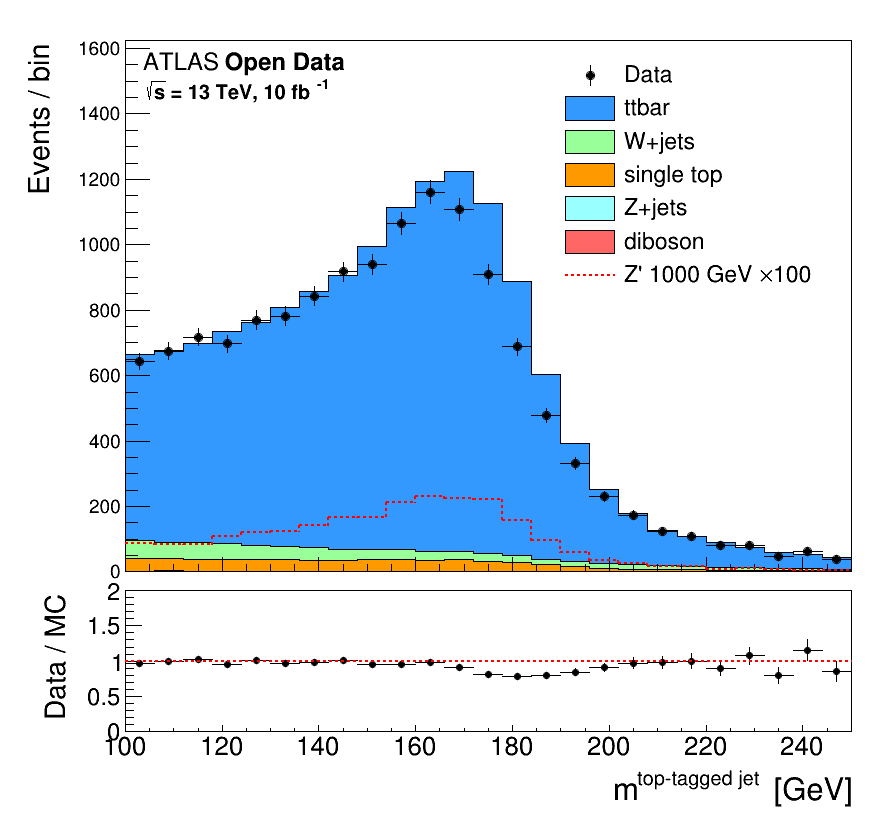

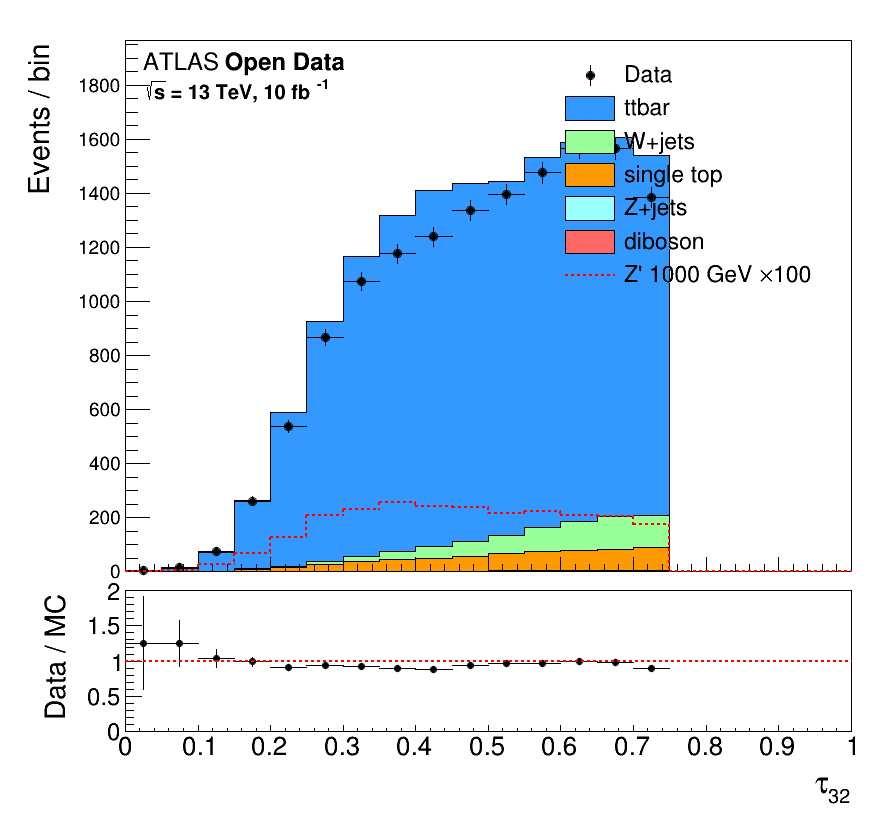

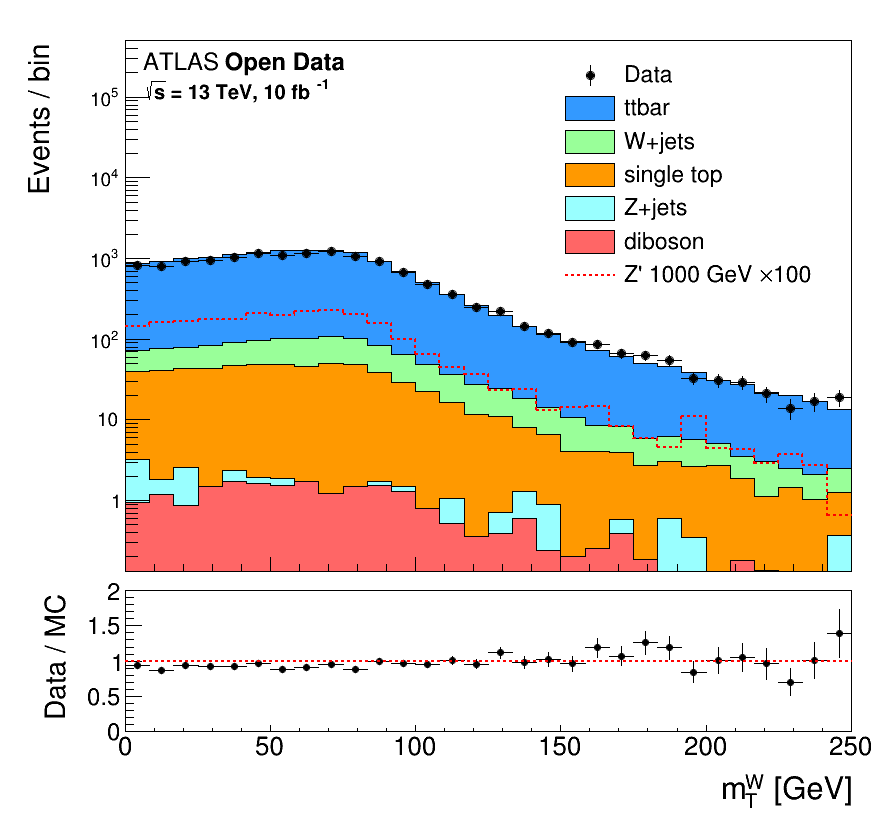

In [ ]:
keep_alive = []

make_kinematic_plot("hist_leadleptpt",         "Lepton p_{T} [GeV]",           "kin_leptpt.png",      logy=True,  sig_scale=100)
make_kinematic_plot("hist_etmiss",             "E_{T}^{miss} [GeV]",           "kin_etmiss.png",      logy=True,  sig_scale=100)
make_kinematic_plot("hist_leadTopLRjet_pt",    "p_{T}^{top-tagged jet} [GeV]", "kin_TopLRjet_pt.png", logy=True,  sig_scale=100)
make_kinematic_plot("hist_leadTopLRjet_m",     "m^{top-tagged jet} [GeV]",     "kin_TopLRjet_m.png",  logy=False, sig_scale=100)
make_kinematic_plot("hist_leadTopLRjet_tau32", "#tau_{32}",                    "kin_tau32.png",       logy=False, sig_scale=100)
make_kinematic_plot("hist_mtw",                "m_{T}^{W} [GeV]",              "kin_mtw.png",         logy=True,  sig_scale=100)


## 10. Signal Shapes

Reconstructed $m_{t\bar t}$ for seven representative $Z'$ masses (×100) over the
total background. With the neutrino now reconstructed via the $W$-mass
constraint, the resonance peaks sit close to their true masses and stay inside
the 400–3400 GeV window. Peaks shift right and broaden with mass; the 400 GeV
point has essentially no boosted acceptance and is omitted.

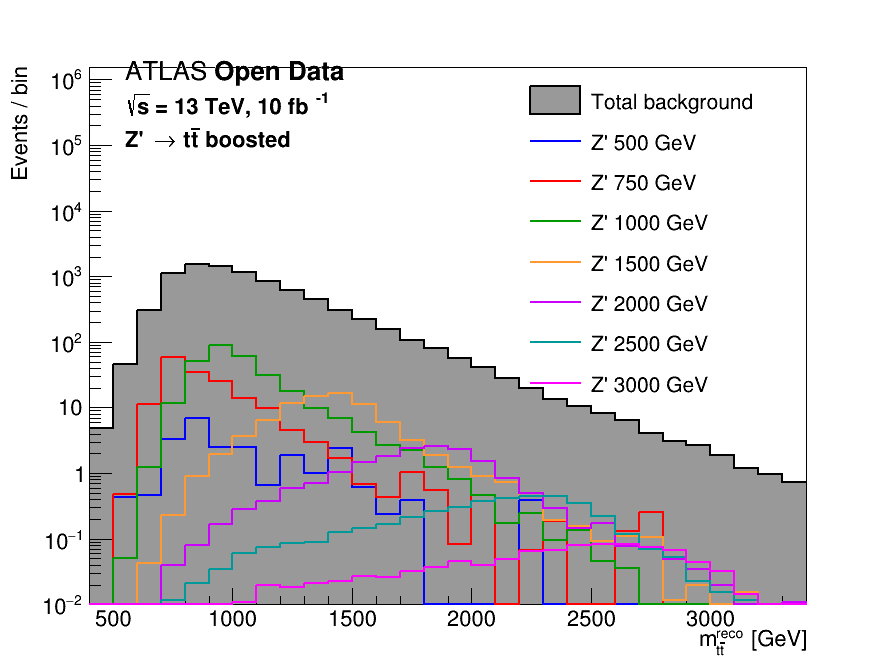

In [10]:
keep_alive = []

c_sig = ROOT.TCanvas("c_sig", "signal shapes", 900, 700)
c_sig.SetLogy(True)

h_bkg_sig = h_bkg_total.Clone("h_bkg_sig_panel")
h_bkg_sig.SetDirectory(0)
h_bkg_sig.SetFillColor(ROOT.kGray+1)
h_bkg_sig.SetLineColor(ROOT.kBlack)
h_bkg_sig.SetLineWidth(2)
h_bkg_sig.SetMinimum(0.01)
h_bkg_sig.SetMaximum(h_bkg_sig.GetMaximum() * 1000)
h_bkg_sig.GetXaxis().SetTitle("m_{t#bar{t}}^{reco} [GeV]")
h_bkg_sig.GetYaxis().SetTitle("Events / bin")
h_bkg_sig.Draw("hist")
keep_alive.append(h_bkg_sig)

sig_colors = [
    ROOT.kBlue, ROOT.kRed, ROOT.kGreen+2, ROOT.kOrange+1,
    ROOT.kViolet, ROOT.kCyan+2, ROOT.kMagenta
]

leg_sig = ROOT.TLegend(0.58, 0.40, 0.90, 0.88)
leg_sig.SetBorderSize(0); leg_sig.SetFillStyle(0); leg_sig.SetTextSize(0.034)
leg_sig.AddEntry(h_bkg_sig, "Total background", "f")

for idx, mass in enumerate([500, 750, 1000, 1500, 2000, 2500, 3000]):
    if mass not in sig_hists:
        continue
    h = sig_hists[mass].Clone(f"sigshape_{mass}")
    h.SetDirectory(0)
    h.Scale(1)
    h.SetLineColor(sig_colors[idx % len(sig_colors)])
    h.SetLineWidth(2)
    h.SetFillStyle(0)
    h.Draw("hist same")
    leg_sig.AddEntry(h, f"Z' {mass} GeV ", "l")
    keep_alive.append(h)

leg_sig.Draw(); keep_alive.append(leg_sig)

latex = ROOT.TLatex(); latex.SetNDC()
latex.SetTextSize(0.042)
latex.DrawLatex(0.14, 0.88, "#bf{ATLAS} Open Data")
latex.SetTextSize(0.036)
latex.DrawLatex(0.14, 0.83, "#sqrt{s} = 13 TeV, 10 fb^{-1}")
latex.DrawLatex(0.14, 0.78, "Z' #rightarrow t#bar{t} boosted")
keep_alive.append(latex)

c_sig.Print("signal_shapes.png"); keep_alive.append(c_sig)
display(Image("signal_shapes.png", width=750))

## 11. CLs Exclusion Fit: Stat-Only

Baseline fit: background is treated as **exact** (no uncertainty on $b$).
One signal strength parameter $\mu$ floated; all other parameters fixed.
This is the simplest possible model and is conservative in the sense that
any mis-modelling of the MC statistical uncertainty would make the limits
too tight (not too loose).

$\mu < 1$ → that mass is **excluded** at 95% CL.

In [11]:

print("Running stat-only CLs scan...\n")
print(f"  {'mass':>6}   {'obs mu<':>9}   {'exp mu<':>9}   {'exp-1s':>9}   {'exp+1s':>9}   status")
print("  " + "-"*62)

fit_results_statonly = {}
for mass in ALL_MASSES:
    obs, exp_set = run_cls_fit(mass, use_mcstat=False)
    fit_results_statonly[mass] = {
        "obs": obs, "exp": exp_set[2],
        "exp_m2": exp_set[0], "exp_m1": exp_set[1],
        "exp_p1": exp_set[3], "exp_p2": exp_set[4],
    }
    tag = "  <- EXCLUDED" if obs < 1.0 else ""
    print(f"  {mass:>6}   {obs:>9.3f}   {exp_set[2]:>9.3f}"
          f"   {exp_set[1]:>9.3f}   {exp_set[3]:>9.3f}{tag}")

print("\nFull quantiles (stat-only):")
print(f"  {'mass':>6}   {'exp-2s':>9}   {'exp-1s':>9}   {'exp':>9}   {'exp+1s':>9}   {'exp+2s':>9}")
print("  " + "-"*62)
for mass in ALL_MASSES:
    r = fit_results_statonly[mass]
    print(f"  {mass:>6}   {r['exp_m2']:>9.3f}   {r['exp_m1']:>9.3f}   {r['exp']:>9.3f}"
          f"   {r['exp_p1']:>9.3f}   {r['exp_p2']:>9.3f}")
print("\nDone.")


Running stat-only CLs scan...

    mass     obs mu<     exp mu<      exp-1s      exp+1s   status
  --------------------------------------------------------------
     400       7.333       9.839       7.077      13.736
     500       4.345       6.494       4.666       9.078
     750       0.560       0.869       0.624       1.215  <- EXCLUDED
    1000       0.442       0.556       0.400       0.776  <- EXCLUDED
    1250       0.431       0.756       0.543       1.057  <- EXCLUDED
    1500       0.691       1.210       0.868       1.694  <- EXCLUDED
    1750       1.305       2.004       1.435       2.813
    2000       1.999       3.269       2.334       4.604
    2250       2.574       5.224       3.717       7.395
    2500       4.297       8.562       6.066      12.191
    2750       7.470      14.259      10.063      20.420
    3000      13.091      24.762      17.357      35.747

Full quantiles (stat-only):
    mass      exp-2s      exp-1s         exp      exp+1s      exp+2s
  --

## 12. CLs Fit: Barlow-Beeston (Cached)

Results are stored in a hardcoded dict (the scan takes ~20 minutes for us and does not need to be rerun everytime). To regenerate, it is enough to uncomment the scan block at the bottom of the code cell, run it, paste the printed values back into the dict, then re-comment the scan block.

The Barlow-Beeston model adds one Gaussian-constrained nuisance parameter per
bin with width $\frac{\delta b_i}{b_i}$, profiled during the scan. Compared to stat-only, limits weaken by 3–6% with no change in exclusion range.

In [12]:
#  Barlow-Beeston results (hardcoded after first run: scan takes ~20 min)
# To regenerate: comment out fit_results_mcstat below, uncomment the scan block,
# run, paste the printed values back, then re-comment the scan.

# Hardcoded results from run on [DATE]:
fit_results_mcstat = {
    400:  {"obs":  7.704, "exp": 10.266, "exp_m1":  7.385, "exp_p1": 14.326, "exp_m2":  5.495, "exp_p2": 19.269},
    500:  {"obs":  4.562, "exp":  6.767, "exp_m1":  4.862, "exp_p1":  9.454, "exp_m2":  3.615, "exp_p2": 12.736},
    750:  {"obs":  0.593, "exp":  0.906, "exp_m1":  0.651, "exp_p1":  1.266, "exp_m2":  0.484, "exp_p2":  1.705},
    1000: {"obs":  0.463, "exp":  0.580, "exp_m1":  0.417, "exp_p1":  0.809, "exp_m2":  0.310, "exp_p2":  1.089},
    1250: {"obs":  0.457, "exp":  0.788, "exp_m1":  0.566, "exp_p1":  1.100, "exp_m2":  0.421, "exp_p2":  1.482},
    1500: {"obs":  0.732, "exp":  1.259, "exp_m1":  0.904, "exp_p1":  1.761, "exp_m2":  0.644, "exp_p2":  2.287},  # NOT excluded
    1750: {"obs":  1.372, "exp":  2.083, "exp_m1":  1.493, "exp_p1":  2.921, "exp_m2":  1.064, "exp_p2":  3.811},
    2000: {"obs":  2.096, "exp":  3.389, "exp_m1":  2.423, "exp_p1":  4.768, "exp_m2":  1.730, "exp_p2":  6.263},
    2250: {"obs":  2.695, "exp":  5.382, "exp_m1":  3.835, "exp_p1":  7.609, "exp_m2":  2.749, "exp_p2": 10.120},
    2500: {"obs":  4.499, "exp":  8.802, "exp_m1":  6.241, "exp_p1": 12.512, "exp_m2":  4.470, "exp_p2": 16.801},
    2750: {"obs":  7.786, "exp": 14.631, "exp_m1": 10.342, "exp_p1": 20.907, "exp_m2":  7.604, "exp_p2": 28.928},
    3000: {"obs": 13.532, "exp": 25.298, "exp_m1": 17.772, "exp_p1": 36.436, "exp_m2": 13.017, "exp_p2": 50.859},
}

print("Barlow-Beeston results loaded from cache.\n")
print(f"  {'mass':>6}   {'obs mu<':>9}   {'exp mu<':>9}   status")
print("  " + "-"*44)
for mass in ALL_MASSES:
    r = fit_results_mcstat[mass]
    tag = "  <- EXCLUDED" if r["obs"] < 1.0 else ""
    print(f"  {mass:>6}   {r['obs']:>9.3f}   {r['exp']:>9.3f}{tag}")

#  SCAN BLOCK (uncomment to regenerate) 
# print("Running CLs scan with MC stat nuisances (Barlow-Beeston)...\n")
# fit_results_mcstat = {}
# for mass in ALL_MASSES:
#     obs, exp_set = run_cls_fit(mass, use_mcstat=True)
#     fit_results_mcstat[mass] = {
#         "obs": obs, "exp": exp_set[2],
#         "exp_m2": exp_set[0], "exp_m1": exp_set[1],
#         "exp_p1": exp_set[3], "exp_p2": exp_set[4],
#     }
#     tag = "  <- EXCLUDED" if obs < 1.0 else ""
#     print(f"  {mass:>6}   {obs:>9.3f}   {exp_set[2]:>9.3f}{tag}")
# print("\nDone. Paste these values into the hardcoded dict above.")

Barlow-Beeston results loaded from cache.

    mass     obs mu<     exp mu<   status
  --------------------------------------------
     400       7.704      10.266
     500       4.562       6.767
     750       0.593       0.906  <- EXCLUDED
    1000       0.463       0.580  <- EXCLUDED
    1250       0.457       0.788  <- EXCLUDED
    1500       0.732       1.259  <- EXCLUDED
    1750       1.372       2.083
    2000       2.096       3.389
    2250       2.695       5.382
    2500       4.499       8.802
    2750       7.786      14.631
    3000      13.532      25.298


## 13. Fit Comparison: Stat-Only vs MC Stat Nuisances

Side-by-side comparison of the observed 95% CL upper limits. The percentage
difference quantifies the impact of MC statistical uncertainties on the result.
A difference of 3–6% with identical exclusion range confirms that the stat-only model is a valid and conservative baseline.

Observed 95% CL upper limits: stat-only vs MC stat nuisances

    mass    stat-only      MC stat      delta    excl SO    excl BB
  --------------------------------------------------------------------
     400        7.333        7.704      +5.1%         no         no
     500        4.345        4.562      +5.0%         no         no
     750        0.560        0.593      +5.9%        YES        YES
    1000        0.442        0.463      +4.7%        YES        YES
    1250        0.431        0.457      +6.0%        YES        YES
    1500        0.691        0.732      +5.9%        YES        YES
    1750        1.305        1.372      +5.1%         no         no
    2000        1.999        2.096      +4.9%         no         no
    2250        2.574        2.695      +4.7%         no         no
    2500        4.297        4.499      +4.7%         no         no
    2750        7.470        7.786      +4.2%         no         no
    3000       13.091       13.532      +3.4%      

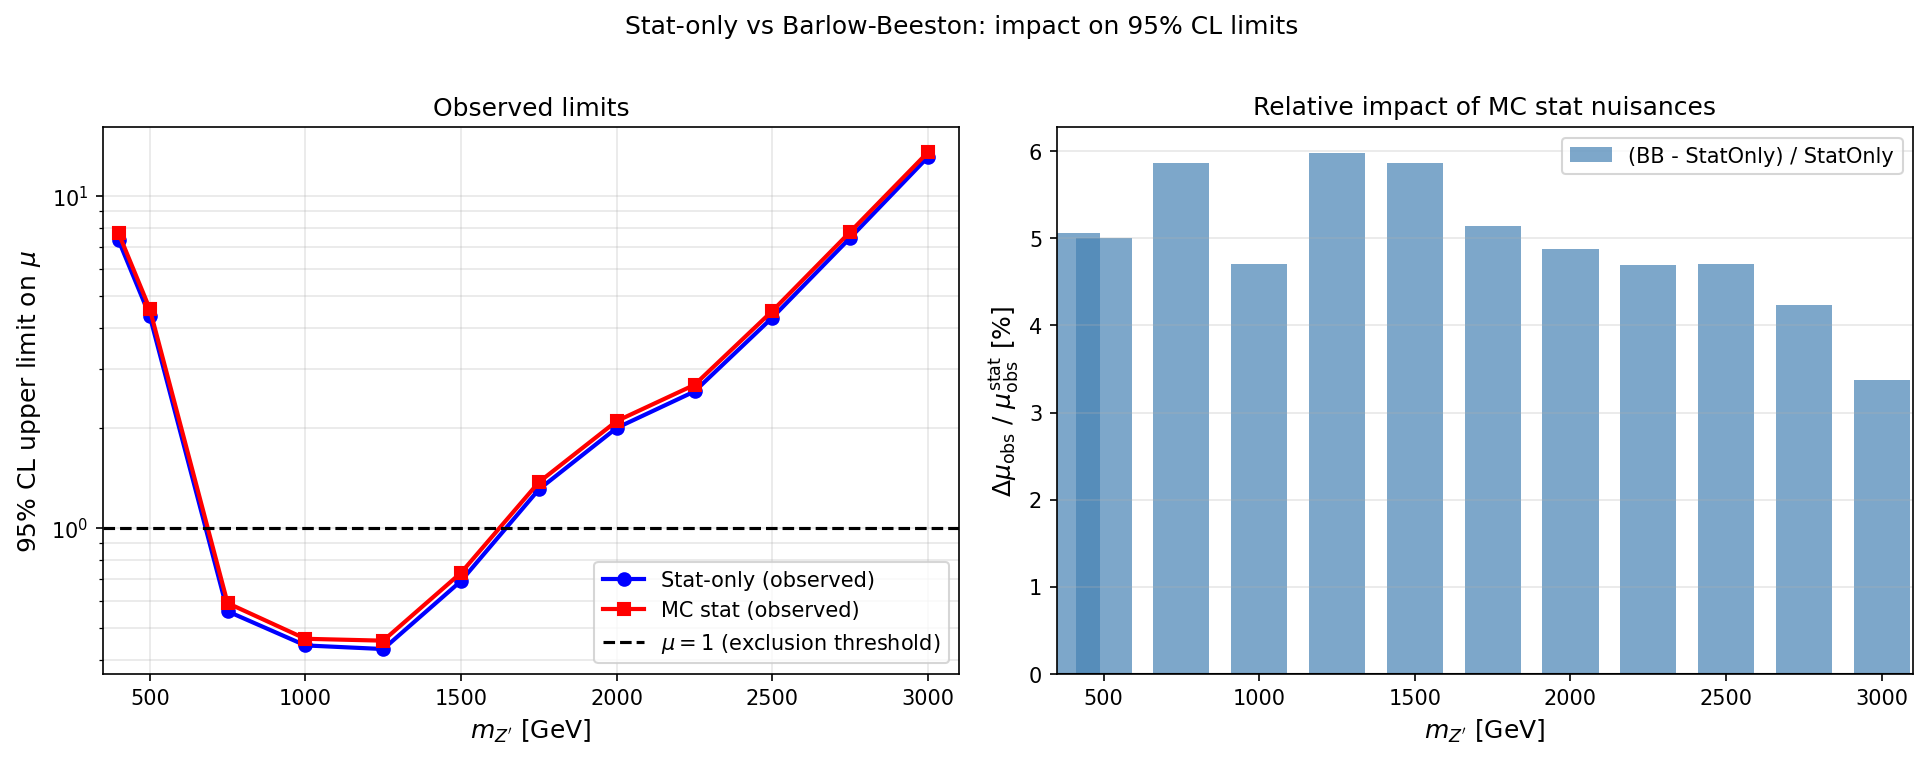


Conclusion: MC stat nuisances weaken limits by ~3-6%.
Exclusion range identical in both fits -> stat-only is a valid baseline.


In [13]:

print("Observed 95% CL upper limits: stat-only vs MC stat nuisances\n")
print(f"  {'mass':>6}   {'stat-only':>10}   {'MC stat':>10}   {'delta':>8}   {'excl SO':>8}   {'excl BB':>8}")
print("  " + "-"*68)
for mass in ALL_MASSES:
    so  = fit_results_statonly[mass]["obs"]
    bb  = fit_results_mcstat[mass]["obs"]
    pct = 100.0 * (bb - so) / so
    ex_so = "YES" if so < 1.0 else "no"
    ex_bb = "YES" if bb < 1.0 else "no"
    print(f"  {mass:>6}   {so:>10.3f}   {bb:>10.3f}   {pct:>+7.1f}%   {ex_so:>8}   {ex_bb:>8}")

#  comparison plot (mu limits, not sigma x BR, cleaner to read) 
masses_arr = np.array(ALL_MASSES, dtype=float)
so_obs = np.array([fit_results_statonly[m]["obs"] for m in ALL_MASSES])
bb_obs = np.array([fit_results_mcstat[m]["obs"]   for m in ALL_MASSES])
so_exp = np.array([fit_results_statonly[m]["exp"]  for m in ALL_MASSES])
bb_exp = np.array([fit_results_mcstat[m]["exp"]    for m in ALL_MASSES])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left: observed limits
ax = axes[0]
ax.semilogy(masses_arr, so_obs, "bo-", lw=2, ms=6, label="Stat-only (observed)")
ax.semilogy(masses_arr, bb_obs, "rs-", lw=2, ms=6, label="MC stat (observed)")
ax.axhline(1.0, color="k", lw=1.5, ls="--", label=r"$\mu = 1$ (exclusion threshold)")
ax.set_xlabel(r"$m_{Z'}$ [GeV]", fontsize=12)
ax.set_ylabel(r"95% CL upper limit on $\mu$", fontsize=12)
ax.set_title("Observed limits", fontsize=12)
ax.set_xlim(350, 3100)
ax.legend(fontsize=10)
ax.grid(True, which="both", alpha=0.3)

# right: percentage difference
ax2 = axes[1]
pct_diff = 100.0 * (bb_obs - so_obs) / so_obs
ax2.bar(masses_arr, pct_diff, width=180, color="steelblue", alpha=0.7, label="(BB - StatOnly) / StatOnly")
ax2.axhline(0, color="k", lw=1)
ax2.set_xlabel(r"$m_{Z'}$ [GeV]", fontsize=12)
ax2.set_ylabel(r"$\Delta\mu_{\rm obs}$ / $\mu_{\rm obs}^{\rm stat}$ [%]", fontsize=12)
ax2.set_title("Relative impact of MC stat nuisances", fontsize=12)
ax2.set_xlim(350, 3100)
ax2.legend(fontsize=10)
ax2.grid(True, axis="y", alpha=0.3)

plt.suptitle("Stat-only vs Barlow-Beeston: impact on 95% CL limits", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("fit_comparison.png", dpi=150, bbox_inches="tight")
plt.close()
display(Image("fit_comparison.png", width=900))
print("\nConclusion: MC stat nuisances weaken limits by ~3-6%.")
print("Exclusion range identical in both fits -> stat-only is a valid baseline.")


## 14. σ×BR Exclusion Curve

We convert the μ limits into physical cross-section limits:

$$\left(\sigma \times \text{BR}\right)_{95\%} = \mu_{95\%} \times \sigma_\text{theory}(m_{Z'})$$

Observed exclusion range (MC stat): 724 - 1605 GeV


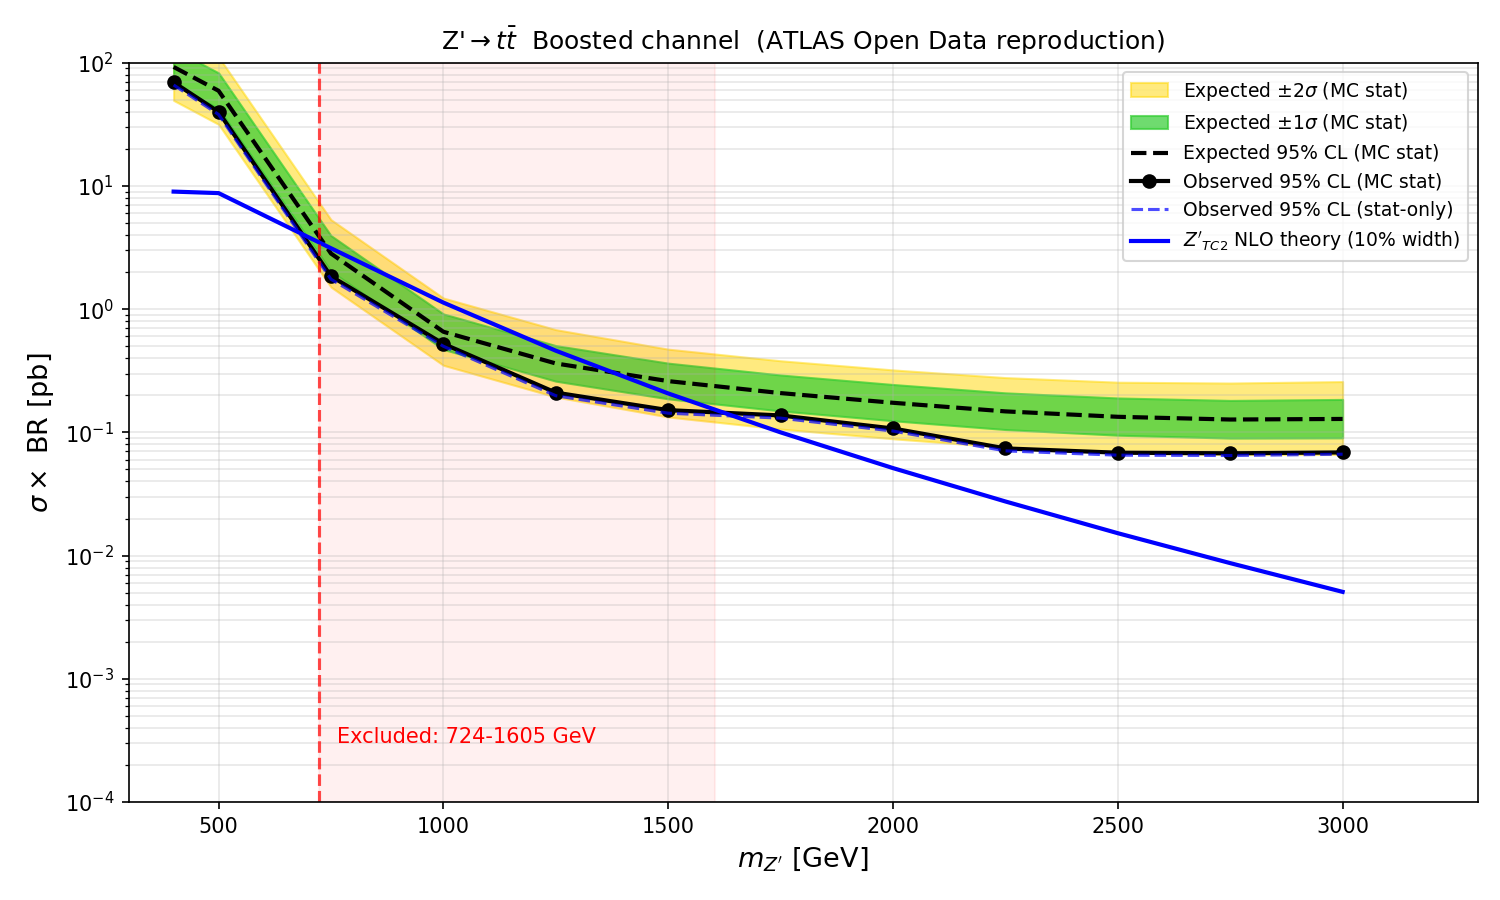

In [14]:
masses_arr  = np.array(ALL_MASSES, dtype=float)
th_xsec_arr = np.array([theory_xsec[m] for m in ALL_MASSES])


bb_obs_xs, bb_exp_xs, bb_m1_xs, bb_p1_xs, bb_m2_xs, bb_p2_xs = make_xs_arrays(fit_results_mcstat)
so_obs_xs, so_exp_xs, *_ = make_xs_arrays(fit_results_statonly)

th_masses_line = np.array(sorted(theory_xsec.keys()), dtype=float)
th_xsec_line   = np.array([theory_xsec[int(m)] for m in th_masses_line])

fig, ax = plt.subplots(figsize=(10, 6))

# expected bands (MC stat, more correct)
ax.fill_between(masses_arr, bb_m2_xs, bb_p2_xs,
                color="gold",      alpha=0.5, label=r"Expected $\pm2\sigma$ (MC stat)")
ax.fill_between(masses_arr, bb_m1_xs, bb_p1_xs,
                color="limegreen", alpha=0.7, label=r"Expected $\pm1\sigma$ (MC stat)")

# expected median (MC stat)
ax.semilogy(masses_arr, bb_exp_xs, "k--", lw=2, label="Expected 95% CL (MC stat)")

# observed: MC stat (primary) + stat-only (secondary)
ax.semilogy(masses_arr, bb_obs_xs, "ko-", lw=2, ms=6, label="Observed 95% CL (MC stat)")
ax.semilogy(masses_arr, so_obs_xs, "b--", lw=1.5, ms=0, alpha=0.7, label="Observed 95% CL (stat-only)")

# theory
ax.semilogy(th_masses_line, th_xsec_line, "b-", lw=2,
            label="$Z'_{TC2}$ NLO theory (10% width)")

ax.set_xlabel(r"$m_{Z'}$ [GeV]", fontsize=13)
ax.set_ylabel(r"$\sigma \times$ BR [pb]", fontsize=13)
ax.set_title(r"Z'$\rightarrow t\bar{t}$  Boosted channel  (ATLAS Open Data reproduction)", fontsize=12)
ax.set_xlim(300, 3300)
ax.set_ylim(1e-4, 100)
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=9, loc="upper right")

# find exclusion crossing for MC stat (primary)
try:
    ratio = interp1d(masses_arr, bb_obs_xs / th_xsec_arr, kind="linear")
    scan  = np.linspace(masses_arr.min(), masses_arr.max(), 5000)
    cross = scan[:-1][np.diff(np.sign(ratio(scan) - 1.0)) != 0]
    if len(cross):
        lo = cross[0]
        hi = cross[-1] if len(cross) > 1 else masses_arr.max()
        ax.axvspan(lo, hi, color="red", alpha=0.06)
        ax.axvline(lo, color="red", lw=1.5, ls="--", alpha=0.7)
        ax.text(lo + 40, 3e-4, f"Excluded: {lo:.0f}-{hi:.0f} GeV",
                color="red", fontsize=10)
        print(f"Observed exclusion range (MC stat): {lo:.0f} - {hi:.0f} GeV")
    else:
        print("No exclusion crossing found.")
except Exception as e:
    print(f"Crossing search error: {e}")

plt.tight_layout()
plt.savefig("excl_xsecBR.png", dpi=150)
plt.close()
display(Image("excl_xsecBR.png", width=850))


## 15. CLs Exclusion: SUSY Signals

The same boosted tt̄ selection and fit machinery applied to the GG (gluino pair) and TT (stop pair) SUSY signal models. No background changes — the 1-lepton boosted channel is the same signal region for all these processes. μ = 1 means the signal is normalized to its theory cross-section; μ_obs < 1.0 $ \rightarrow$ excluded at 95% CL.

The fit is stat-only (same as the Z' baseline). Results are interpreted as observed upper limits on μ for each model.

Running CLs scan for SUSY signals (stat-only)...

  model                            obs mu<     exp mu<      exp-1s      exp+1s   status
  --------------------------------------------------------------------------------
  GG_ttn1_1200_5000_1                1.272       2.672       1.910       3.757
  GG_ttn1_1200_5000_600              4.725       9.205       6.617      12.866
  GG_ttn1_1400_5000_1                3.259       6.797       4.839       9.615
  GG_ttn1_1600_5000_1                0.840       1.742       1.233       2.482  <- EXCLUDED
  TT_directTT_450_1                  1.009       1.993       1.428       2.794
  TT_directTT_500_1                  1.360       2.734       1.950       3.853
  TT_directTT_500_200                2.372       4.709       3.366       6.617
  TT_directTT_600_1                  3.150       6.158       4.414       8.631

Full quantiles (SUSY stat-only):
  model                             exp-2s      exp-1s         exp      exp+1s      exp+2s
  -------

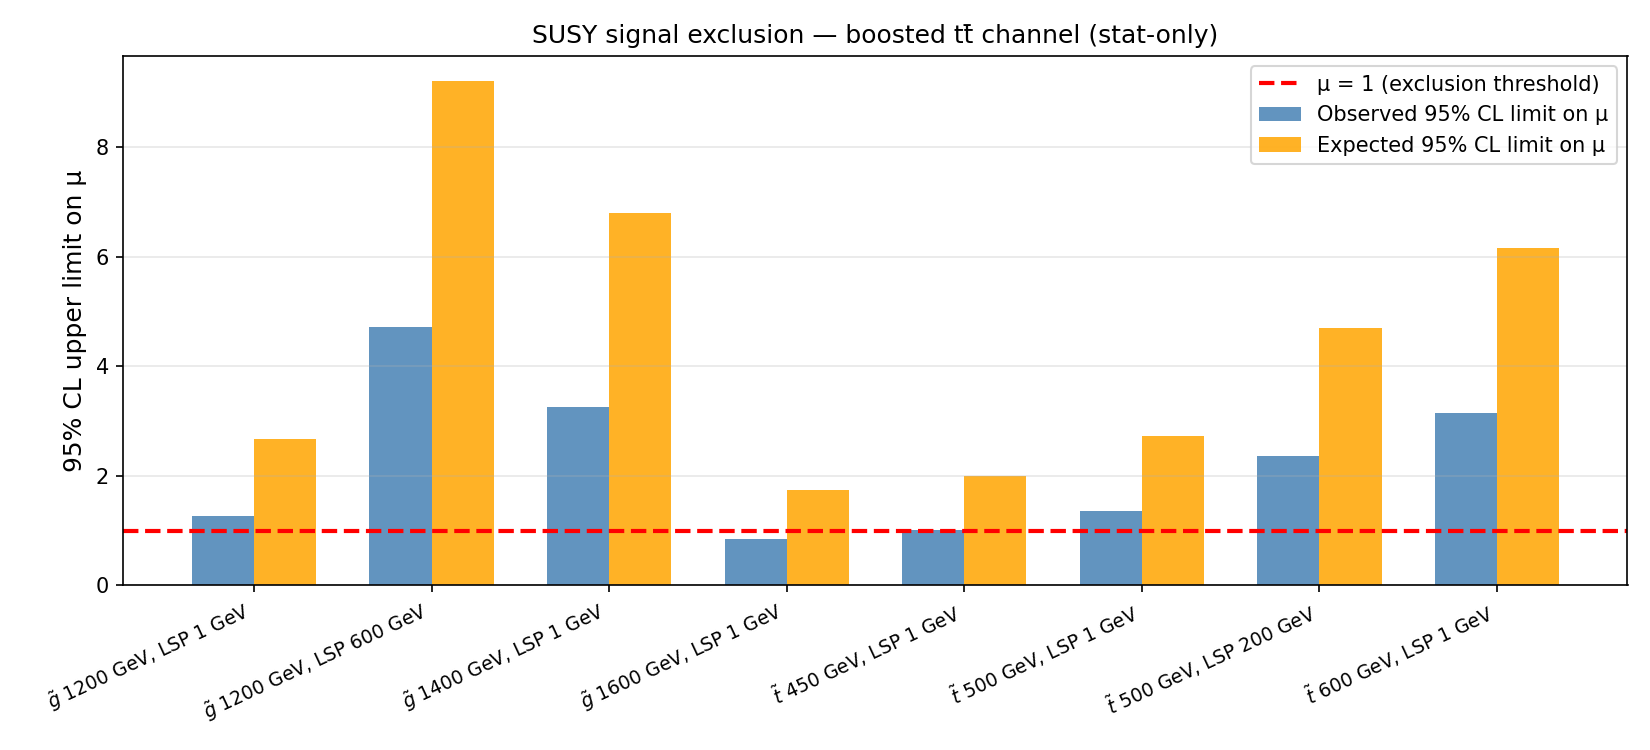


Models with obs < 1.0 are excluded at 95% CL by this analysis.


In [15]:
print("Running CLs scan for SUSY signals (stat-only)...\n")
print(f"  {'model':<28}   {'obs mu<':>9}   {'exp mu<':>9}   {'exp-1s':>9}   {'exp+1s':>9}   status")
print("  " + "-"*80)

fit_results_susy = {}
for name, h in susy_hists.items():
    obs, exp_set = run_cls_fit(name, use_mcstat=False)
    if obs is None:
        print(f"  {name:<28}   FIT FAILED")
        continue
    fit_results_susy[name] = {
        "obs": obs, "exp": exp_set[2],
        "exp_m2": exp_set[0], "exp_m1": exp_set[1],
        "exp_p1": exp_set[3], "exp_p2": exp_set[4],
    }
    tag = "  <- EXCLUDED" if obs < 1.0 else ""
    print(f"  {name:<28}   {obs:>9.3f}   {exp_set[2]:>9.3f}"
          f"   {exp_set[1]:>9.3f}   {exp_set[3]:>9.3f}{tag}")

print("\nFull quantiles (SUSY stat-only):")
print(f"  {'model':<28}   {'exp-2s':>9}   {'exp-1s':>9}   {'exp':>9}   {'exp+1s':>9}   {'exp+2s':>9}")
print("  " + "-"*80)
for name, r in fit_results_susy.items():
    print(f"  {name:<28}   {r['exp_m2']:>9.3f}   {r['exp_m1']:>9.3f}   {r['exp']:>9.3f}"
          f"   {r['exp_p1']:>9.3f}   {r['exp_p2']:>9.3f}")

# bar chart of observed limits
fig, ax = plt.subplots(figsize=(11, 5))
names  = list(fit_results_susy.keys())
labels = [SUSY_SIGNALS[n]["label"] for n in names]
obs_vals = [fit_results_susy[n]["obs"] for n in names]
exp_vals = [fit_results_susy[n]["exp"] for n in names]
x = np.arange(len(names))
w = 0.35

bars_obs = ax.bar(x - w/2, obs_vals, w, label="Observed 95% CL limit on μ",
                  color="steelblue", alpha=0.85)
bars_exp = ax.bar(x + w/2, exp_vals, w, label="Expected 95% CL limit on μ",
                  color="orange", alpha=0.85)

ax.axhline(1.0, color="red", lw=2, ls="--", label="μ = 1 (exclusion threshold)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("95% CL upper limit on μ", fontsize=12)
ax.set_title("SUSY signal exclusion — boosted tt̄ channel (stat-only)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("susy_exclusion.png", dpi=150)
plt.close()
display(Image("susy_exclusion.png", width=900))

print("\nModels with obs < 1.0 are excluded at 95% CL by this analysis.")